<a href="https://colab.research.google.com/github/tilkov03/Recommended-driving-speed/blob/main/%D0%A1%D0%BA%D0%BE%D1%80%D0%BE%D1%81%D1%82_%D0%BF%D1%80%D0%B8_%D1%88%D0%BE%D1%84%D0%B8%D1%80%D0%B0%D0%BD%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
!pip install scikit-fuzzy

In [50]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [51]:
# Входове
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
visibility = ctrl.Antecedent(np.arange(0, 101, 1), 'visibility')
weather = ctrl.Antecedent(np.arange(0, 101, 1), 'weather')

# Изход
speed = ctrl.Consequent(np.arange(0, 131, 1), 'speed')

In [52]:
# Traffic
traffic['low'] = fuzz.trimf(traffic.universe, [0, 0, 50])
traffic['medium'] = fuzz.trimf(traffic.universe, [20, 50, 80])
traffic['high'] = fuzz.trimf(traffic.universe, [60, 100, 100])

# Visibility
visibility['poor'] = fuzz.trimf(visibility.universe, [0, 0, 40])
visibility['average'] = fuzz.trimf(visibility.universe, [20, 50, 80])
visibility['good'] = fuzz.trimf(visibility.universe, [60, 100, 100])

# Weather
weather['bad'] = fuzz.trimf(weather.universe, [0, 0, 40])
weather['ok'] = fuzz.trimf(weather.universe, [20, 50, 80])
weather['good'] = fuzz.trimf(weather.universe, [60, 100, 100])

# Speed
speed['slow'] = fuzz.trimf(speed.universe, [0, 0, 60])
speed['medium'] = fuzz.trimf(speed.universe, [40, 70, 100])
speed['fast'] = fuzz.trimf(speed.universe, [80, 130, 130])

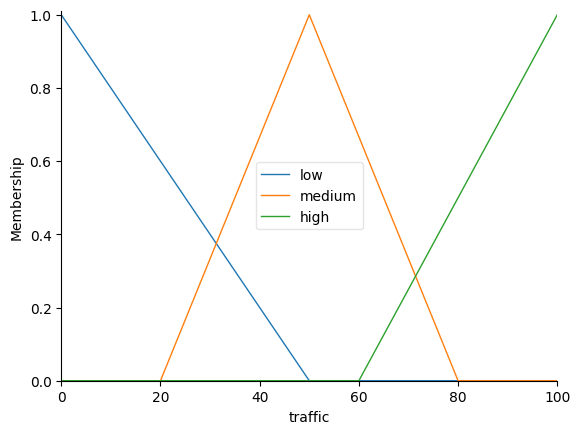

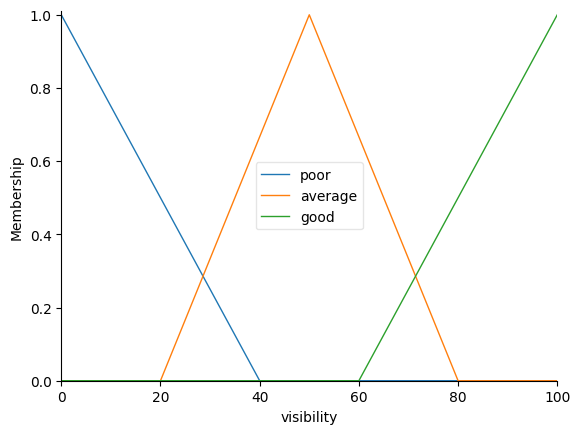

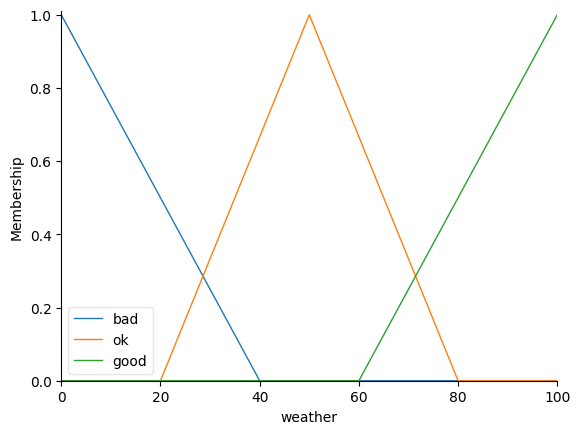

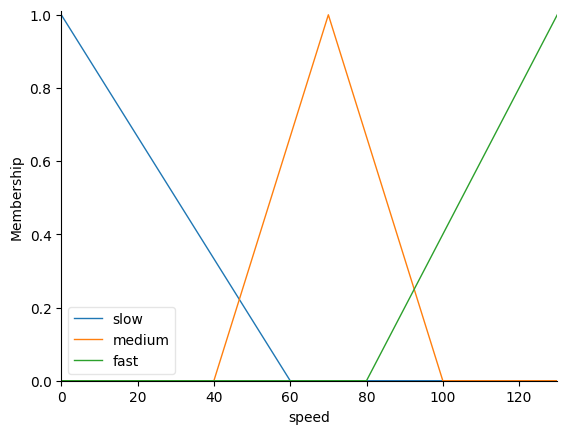

In [53]:
traffic.view()
visibility.view()
weather.view()
speed.view()

In [54]:
rule1 = ctrl.Rule(traffic['high'] | visibility['poor'], speed['slow'])
rule2 = ctrl.Rule(traffic['medium'] & weather['ok'], speed['medium'])
rule3 = ctrl.Rule(traffic['low'] & visibility['good'] & weather['good'], speed['fast'])
rule4 = ctrl.Rule(weather['bad'], speed['slow'])
rule5 = ctrl.Rule(visibility['average'], speed['medium'])

In [55]:
speed_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])
speed_sim = ctrl.ControlSystemSimulation(speed_ctrl)

Recommended speed: 84.47095435684646


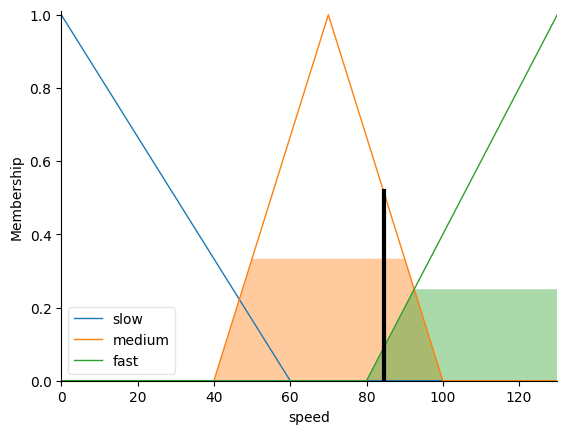

In [56]:
speed_sim.input['traffic'] = 30
speed_sim.input['visibility'] = 70
speed_sim.input['weather'] = 80

speed_sim.compute()

print("Recommended speed:", speed_sim.output['speed'])

speed.view(sim=speed_sim)

In [57]:
# Функция за тестване
def test_case(t, v, w):
    speed_sim.input['traffic'] = t
    speed_sim.input['visibility'] = v
    speed_sim.input['weather'] = w
    speed_sim.compute()

    print(f"Traffic={t}, Visibility={v}, Weather={w} → Speed={speed_sim.output['speed']:.2f}")

In [58]:
# ЛОШИ условия
test_case(90, 20, 10)

# СРЕДНИ условия
test_case(50, 50, 50)

# ДОБРИ условия
test_case(10, 90, 90)

# Лошо време
test_case(20, 80, 10)

# Лоша видимост
test_case(30, 10, 80)

Traffic=90, Visibility=20, Weather=10 → Speed=21.00
Traffic=50, Visibility=50, Weather=50 → Speed=70.00
Traffic=10, Visibility=90, Weather=90 → Speed=112.50
Traffic=20, Visibility=80, Weather=10 → Speed=21.00
Traffic=30, Visibility=10, Weather=80 → Speed=21.00


In [59]:
rule6 = ctrl.Rule(traffic['low'] & weather['bad'], speed['medium'])
rule7 = ctrl.Rule(traffic['high'] & visibility['good'], speed['medium'])

In [60]:
speed_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])

In [61]:
import pandas as pd

results = []

test_inputs = [
    (90, 20, 10),
    (50, 50, 50),
    (10, 90, 90),
    (20, 80, 10),
    (30, 10, 80),
    (70, 60, 40),
    (15, 85, 95)
]

for t, v, w in test_inputs:
    speed_sim.input['traffic'] = t
    speed_sim.input['visibility'] = v
    speed_sim.input['weather'] = w
    speed_sim.compute()

    results.append({
        "Traffic": t,
        "Visibility": v,
        "Weather": w,
        "Recommended Speed": round(speed_sim.output['speed'], 2)
    })

df = pd.DataFrame(results)
df

,Traffic,Visibility,Weather,Recommended Speed
0,90,20,10,21.00
1,50,50,50,70.00
2,10,90,90,112.50
3,20,80,10,21.00
4,30,10,80,21.00
5,70,60,40,56.03
6,15,85,95,111.63


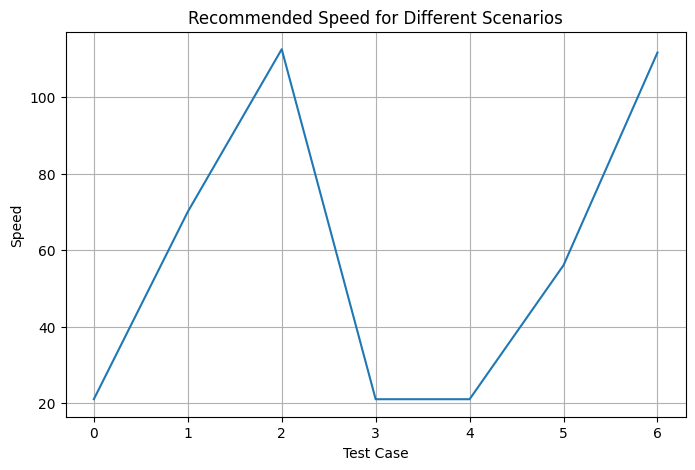

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df["Recommended Speed"])
plt.title("Recommended Speed for Different Scenarios")
plt.xlabel("Test Case")
plt.ylabel("Speed")
plt.grid()

plt.show()

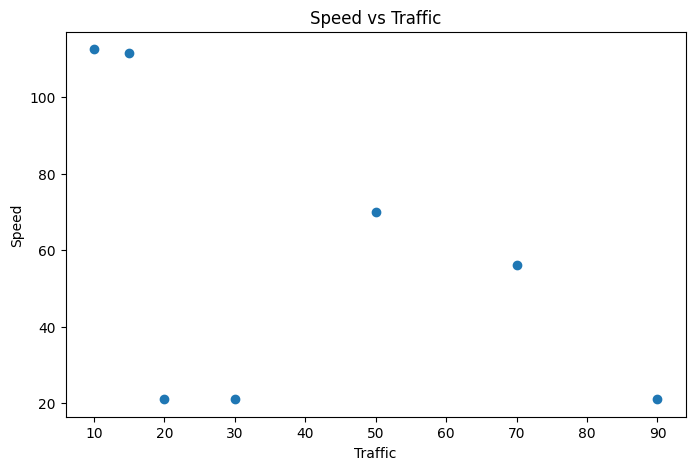

In [63]:
plt.figure(figsize=(8,5))
plt.scatter(df["Traffic"], df["Recommended Speed"])
plt.xlabel("Traffic")
plt.ylabel("Speed")
plt.title("Speed vs Traffic")

plt.show()

In [64]:
from ipywidgets import interact

def fuzzy_drive(traffic_val, visibility_val, weather_val):
    speed_sim.input['traffic'] = traffic_val
    speed_sim.input['visibility'] = visibility_val
    speed_sim.input['weather'] = weather_val
    speed_sim.compute()

    result = speed_sim.output['speed']
    print(f"Recommended speed: {result:.2f} km/h")

interact(
    fuzzy_drive,
    traffic_val=(0, 100, 5),
    visibility_val=(0, 100, 5),
    weather_val=(0, 100, 5)
)

interactive(children=(IntSlider(value=50, description='traffic_val', step=5), IntSlider(value=50, description=…

<function __main__.fuzzy_drive(traffic_val, visibility_val, weather_val)>

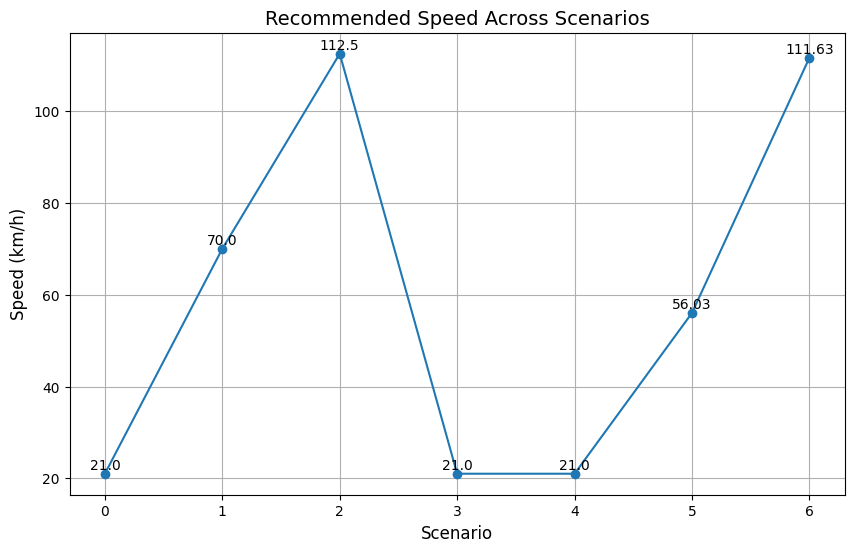

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(df["Recommended Speed"], marker='o')
plt.title("Recommended Speed Across Scenarios", fontsize=14)
plt.xlabel("Scenario", fontsize=12)
plt.ylabel("Speed (km/h)", fontsize=12)
plt.grid(True)

for i, val in enumerate(df["Recommended Speed"]):
    plt.text(i, val+1, str(val), ha='center')

plt.show()

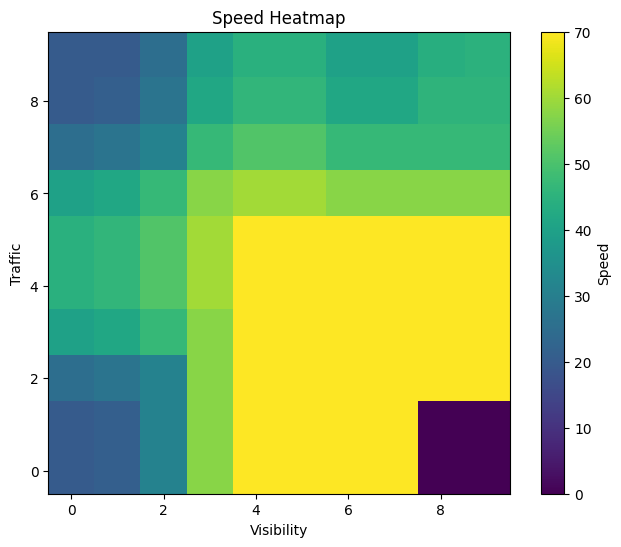

In [66]:
import numpy as np

traffic_range = np.linspace(0, 100, 10)
visibility_range = np.linspace(0, 100, 10)

Z = np.zeros((10,10))

for i, t in enumerate(traffic_range):
    for j, v in enumerate(visibility_range):

        sim = ctrl.ControlSystemSimulation(speed_ctrl)

        sim.input['traffic'] = t
        sim.input['visibility'] = v
        sim.input['weather'] = 50

        try:
            sim.compute()
            Z[i, j] = sim.output['speed']
        except:
            Z[i, j] = 0  # fallback стойност

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(Z, origin='lower')
plt.colorbar(label="Speed")
plt.title("Speed Heatmap")
plt.xlabel("Visibility")
plt.ylabel("Traffic")

plt.show()

In [67]:
rule8 = ctrl.Rule(traffic['medium'] & visibility['good'], speed['medium'])
rule9 = ctrl.Rule(traffic['low'] & visibility['poor'], speed['slow'])

In [68]:
speed_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9
])

In [69]:
##УМНА ФУНКЦИЯ ЗА ТЕСТ:
def test_case(t, v, w):
    sim = ctrl.ControlSystemSimulation(speed_ctrl)

    sim.input['traffic'] = t
    sim.input['visibility'] = v
    sim.input['weather'] = w

    sim.compute()

    result = sim.output['speed']

    print(f"Traffic={t}, Visibility={v}, Weather={w} → Speed={result:.2f} km/h")

    return result

In [70]:
print("=== ОСНОВНИ СЦЕНАРИИ ===")

# Много лоши условия
test_case(90, 10, 10)

# Средни условия
test_case(50, 50, 50)

# Перфектни условия
test_case(10, 90, 90)

=== ОСНОВНИ СЦЕНАРИИ ===
Traffic=90, Visibility=10, Weather=10 → Speed=21.00 km/h
Traffic=50, Visibility=50, Weather=50 → Speed=70.00 km/h
Traffic=10, Visibility=90, Weather=90 → Speed=112.50 km/h


np.float64(112.5)

In [71]:
print("\n=== РЕАЛНИ СИТУАЦИИ ===")

# Магистрала, ясно време
test_case(20, 90, 90)

# Градски трафик
test_case(80, 60, 70)

# Нощ + мъгла
test_case(40, 20, 60)

# Дъжд
test_case(30, 70, 20)

# Натоварен път + лоша видимост
test_case(85, 25, 30)


=== РЕАЛНИ СИТУАЦИИ ===
Traffic=20, Visibility=90, Weather=90 → Speed=111.43 km/h
Traffic=80, Visibility=60, Weather=70 → Speed=48.63 km/h
Traffic=40, Visibility=20, Weather=60 → Speed=48.63 km/h
Traffic=30, Visibility=70, Weather=20 → Speed=44.59 km/h
Traffic=85, Visibility=25, Weather=30 → Speed=33.71 km/h


np.float64(33.712361331220244)

In [72]:
import pandas as pd

test_data = [
    ("Bad conditions", 90, 10, 10),
    ("Average", 50, 50, 50),
    ("Perfect", 10, 90, 90),
    ("High traffic", 80, 60, 70),
    ("Rain", 30, 70, 20),
    ("Fog", 40, 20, 60),
    ("Extreme bad", 100, 0, 0)
]

results = []

for name, t, v, w in test_data:
    speed_val = test_case(t, v, w)

    results.append({
        "Scenario": name,
        "Traffic": t,
        "Visibility": v,
        "Weather": w,
        "Speed": round(speed_val, 2)
    })

df = pd.DataFrame(results)
df

Traffic=90, Visibility=10, Weather=10 → Speed=21.00 km/h
Traffic=50, Visibility=50, Weather=50 → Speed=70.00 km/h
Traffic=10, Visibility=90, Weather=90 → Speed=112.50 km/h
Traffic=80, Visibility=60, Weather=70 → Speed=48.63 km/h
Traffic=30, Visibility=70, Weather=20 → Speed=44.59 km/h
Traffic=40, Visibility=20, Weather=60 → Speed=48.63 km/h
Traffic=100, Visibility=0, Weather=0 → Speed=20.00 km/h


,Scenario,Traffic,Visibility,Weather,Speed
0,Bad conditions,90,10,10,21.00
1,Average,50,50,50,70.00
2,Perfect,10,90,90,112.50
3,High traffic,80,60,70,48.63
4,Rain,30,70,20,44.59
5,Fog,40,20,60,48.63
6,Extreme bad,100,0,0,20.00


##Анализ на тестовете

От проведените тестове се наблюдава:

- При висок трафик скоростта значително намалява
- Лошите метеорологични условия водят до по-ниска скорост
- Добрата видимост увеличава препоръчителната скорост
- При комбинирани лоши условия резултатът е минимална скорост

Системата демонстрира логично и последователно поведение.

In [73]:
def interpret_speed(s):
    if s < 50:
        return "Low"
    elif s < 90:
        return "Medium"
    else:
        return "High"

df["Category"] = df["Speed"].apply(interpret_speed)
df

,Scenario,Traffic,Visibility,Weather,Speed,Category
0,Bad conditions,90,10,10,21.00,Low
1,Average,50,50,50,70.00,Medium
2,Perfect,10,90,90,112.50,High
3,High traffic,80,60,70,48.63,Low
4,Rain,30,70,20,44.59,Low
5,Fog,40,20,60,48.63,Low
6,Extreme bad,100,0,0,20.00,Low
